# Project 3 - Lab 2 - Time Series Data Visualization

In [2]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
sns.set_style('whitegrid')
sns.set_palette('deep')

## Understanding the NGSIM Data

Next Generation Simulation (NGSIM) data (https://ops.fhwa.dot.gov/trafficanalysistools/ngsim.htm) is one of the most influential dataset collected and released by the U.S. Department of Transportation - Federal Highway Administration. The goal of this data is to "To develop a core of open behavioral algorithms in support of traffic simulation with a primary focus on microscopic modeling, including supporting documentation and validation data sets that describe the interactions of multimodal travelers, vehicles and highway systems, and interactions presented to them from traffic control devices, delineation, congestion, and other features of the environment." 

Much of what we know now about driving behavior comes from this dataset. This has a huge impact on the way we design, manage, and operate our transportation system. Similar dataset exists for various commercially available automated vehicles.

In [4]:
# Load the NGSIM dataset
ngsim_data = pd.read_csv('NGSIM(in).csv')

# Print the dataset and show its attributes
ngsim_data.head()

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,26.654,0.0000,14.054,14.484,1.09730,-3.048000e-02,1
1,0.2,28.060,1.4484,14.164,14.481,-1.00580,-3.048000e-02,1
2,0.3,29.476,2.8965,14.063,14.478,-2.28600,6.096000e-02,1
3,0.4,30.882,4.3443,13.835,14.484,-0.88392,-3.048000e-02,1
4,0.5,32.266,5.7927,13.746,14.481,0.85344,1.780000e-13,1


In [5]:
### Understanding the Data Structure
print("Columns in dataset:", ngsim_data.columns)
print("Dataset info:")
print(ngsim_data.info())


Columns in dataset: Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8166 entries, 0 to 8165
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time                  8166 non-null   float64
 1   leader_position(m)    8166 non-null   float64
 2   follower_position(m)  8166 non-null   float64
 3   leader_speed(m/s)     8166 non-null   float64
 4   follower_speed(m/s)   8166 non-null   float64
 5   leader_acc(m/s^2)     8166 non-null   float64
 6   follower_acc(m/s^2)   8166 non-null   float64
 7   trajectory_number     8166 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 510.5 KB
None


### Lab Activity #1
Take some time now, to open the NGSIM.csv excel file and understand the data 


Write here three different observations/knowledge you gathered from the data 
1.   Most data is in the "float" data type, or has a decimal associated with it.
2.  The data set is complete with no missing values. 
3.   The data represents leader-follower vehicle dynamics. 

## Exploring the Data Numerically

Before we plot anything, let's use descriptive statistics to understand the range and distribution of values in our dataset. This will help us interpret the graphs later.

In [6]:
# Get descriptive statistics for the full dataset
# This gives us the mean, std, min, max, and quartiles for each column
ngsim_data.describe()


,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
count,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000
mean,27.929611,266.263343,246.576350,8.745533,8.776852,-0.059325,-0.035836,8.176708
std,19.131202,135.110878,134.904708,3.695903,3.784383,1.666269,1.765766,4.811499
min,0.100000,8.227800,0.000000,0.000000,0.000000,-15.240000,-15.240000,1.000000
25%,12.800000,161.337500,141.870000,6.096000,6.096000,-0.365760,-0.365760,4.000000
50%,25.600000,254.180000,237.925000,9.121150,9.128800,0.000000,0.000000,8.000000
75%,38.300000,365.700000,344.990000,12.064000,12.133250,0.335280,0.365760,13.000000
max,84.100000,651.500000,619.050000,17.221000,17.898000,8.046700,15.240000,16.000000


In [9]:
# How many unique trajectory pairs (vehicle pairs) do we have?
# How many time steps does each trajectory have?

print(ngsim_data['trajectory_number'].nunique())

# hint: use .groupby('trajectory_number').size() to count rows per trajectory

print(ngsim_data.groupby('trajectory_number').size())

16
trajectory_number
1     841
2     398
3     483
4     826
5     401
6     438
7     506
8     394
9     401
10    432
11    447
12    419
13    802
14    448
15    398
16    532
dtype: int64


## Time Series Plottings


Time series data is a sequence of data points recorded at successive time intervals. Plotting time series data means plotting some variable against a time attribute. 
In transportation studies, time series data helps us understand vehicle movement and behavior. 

Let us then start exploring this data


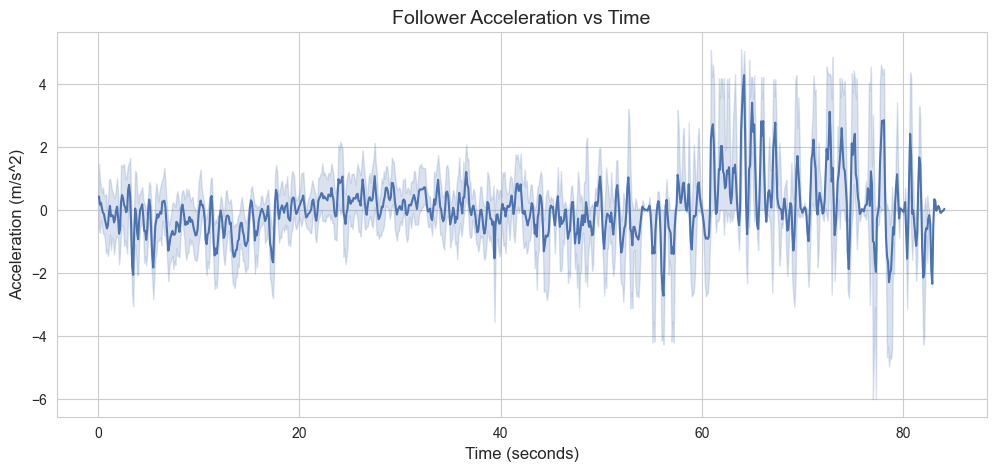

In [12]:
### Plotting Acceleration vs Time

# We are interested in analyzing the acceleration profile of the follower vehicles (follower_acc(m/s^2)) as function of time. Follow the steps we have learned from previous lab to do so. 
# hint we need to use the sns.lineplot 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize = (12,5))

# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)

sns.lineplot(x = ngsim_data['Time'],y = ngsim_data['leader_acc(m/s^2)'])

# Step 3: add customizations
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Acceleration (m/s^2)', fontsize = 12)
plt.title('Follower Acceleration vs Time', fontsize = 14)
plt.show()

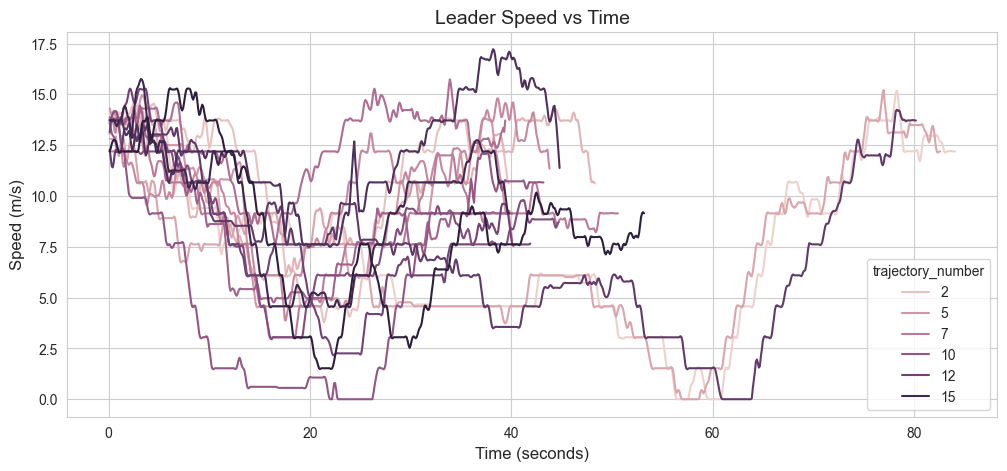

In [15]:
### Plotting Speed vs Time

plt.figure(figsize = (12,5))

# replicate the above steps, but now visualize the follower_speed(m/s) data with time 

sns.lineplot(x = ngsim_data['Time'],y = ngsim_data['leader_speed(m/s)'], hue = ngsim_data['trajectory_number'])

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Speed (m/s)', fontsize = 12)
plt.title('Leader Speed vs Time', fontsize = 14)
plt.show()

### Lab Activity #2: Position vs. Time
In the cell below, show that you have plotted position versus time for the same data as above in the Speed vs. Time plot

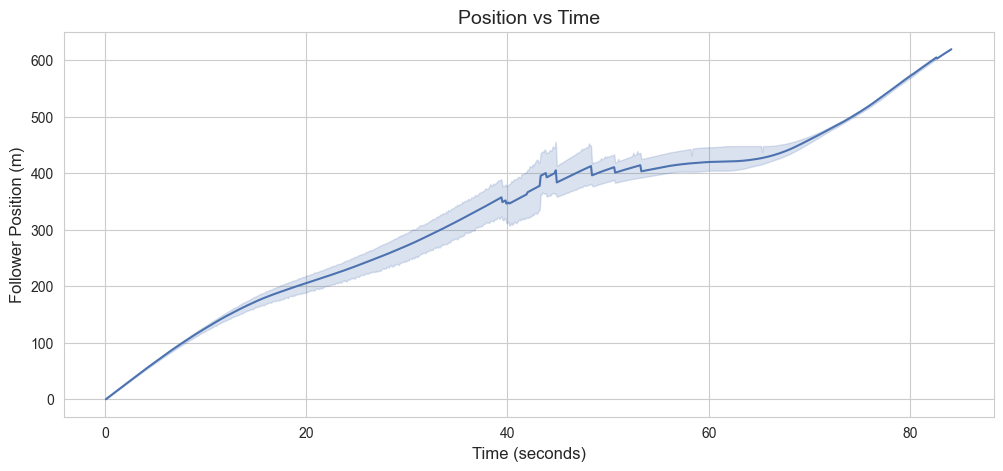

In [14]:
### Plotting Position vs Time

plt.figure(figsize = (12,5))

# replicate the above steps, but now visualize the follower_position(m) data with time 

sns.lineplot(x = ngsim_data['Time'],y = ngsim_data['follower_position(m)'])

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Follower Position (m)', fontsize = 12)
plt.title('Position vs Time', fontsize = 14)
plt.show()

### Using Subplots for Comparison

A very useful technique in data visualization is **subplots** — placing multiple plots in one figure. This allows us to compare related information side by side.

Let's create a figure with 3 subplots stacked vertically, showing position, speed, and acceleration of the follower vehicle all together. This gives us a complete picture of the vehicle's motion at a glance.

The basic structure is:
```python
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)  # 3 rows, 1 column, shared x-axis
axes[0].plot(...)  # first plot
axes[1].plot(...)  # second plot
axes[2].plot(...)  # third plot
```

## Plotting for each Vehicle Pair Alone


You can notice that we have been plotting all acceleration of different vehicles together. However, if we want to understand vehicle behavior we want to focus on vehicle pair (leader-follower) and learn their characteristics. 

In traffic studies, this is referred to as car-following analysis: how one vehicle follows another in traffic. 

In the following we want to choose some vehicle pair and analyze their behavior

### Lab Activity #3: Choose a Trajectory number different from Dr. Lane!
Our TA will be looking to see if your trajectory number is different from Dr. Lane

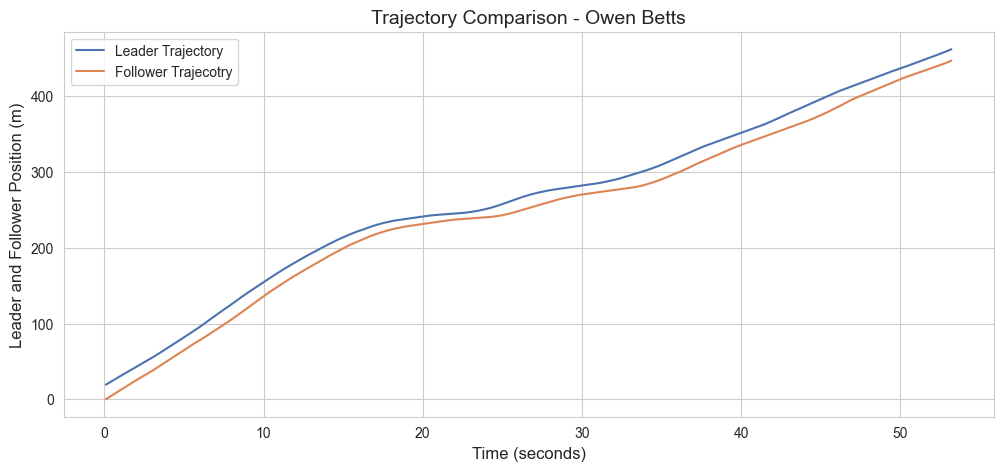

In [23]:
# Select a trajectory number
trajectory_number = 16 # vehicle pair x

# select the data based on the subset 

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

# Plot the position of both vehicles over time
# follow similar steps of what we learned
# but here you need to plot two lines together:
    # one lineplot for leader position vs time 
    # another lineplot for follower position vs time

plt.figure(figsize = (12,5))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_position(m)', label = 'Leader Trajectory')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_position(m)', label = 'Follower Trajecotry')

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Leader and Follower Position (m)', fontsize = 12)
plt.title('Trajectory Comparison - Owen Betts', fontsize = 14)
plt.legend()

plt.show()


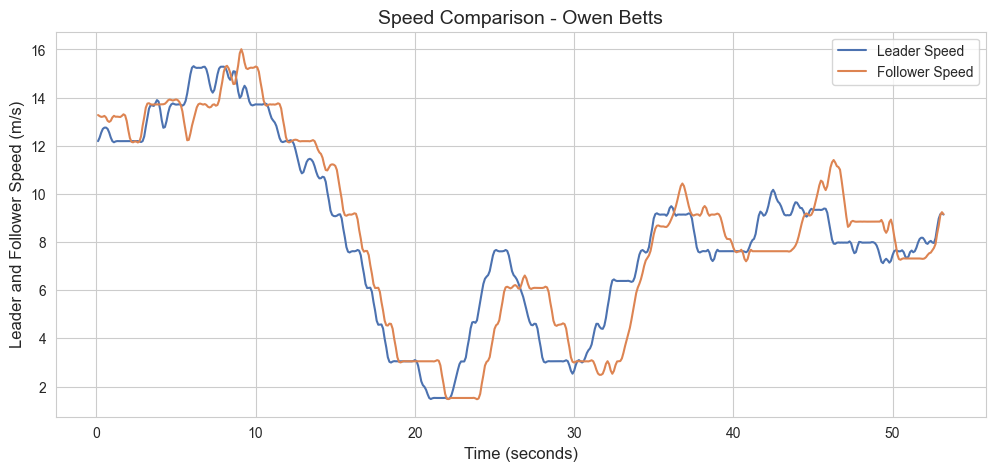

In [24]:
# Now replicate the same but visualizing speed
# Select a trajectory number
trajectory_number = 16 # vehicle pair x

# select the data based on the subset 

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

# Plot the position of both vehicles over time
# follow similar steps of what we learned
# but here you need to plot two lines together:
    # one lineplot for leader position vs time 
    # another lineplot for follower position vs time

plt.figure(figsize = (12,5))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_speed(m/s)', label = 'Leader Speed')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_speed(m/s)', label = 'Follower Speed')

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Leader and Follower Speed (m/s)', fontsize = 12)
plt.title('Speed Comparison - Owen Betts', fontsize = 14)
plt.legend()

plt.show()


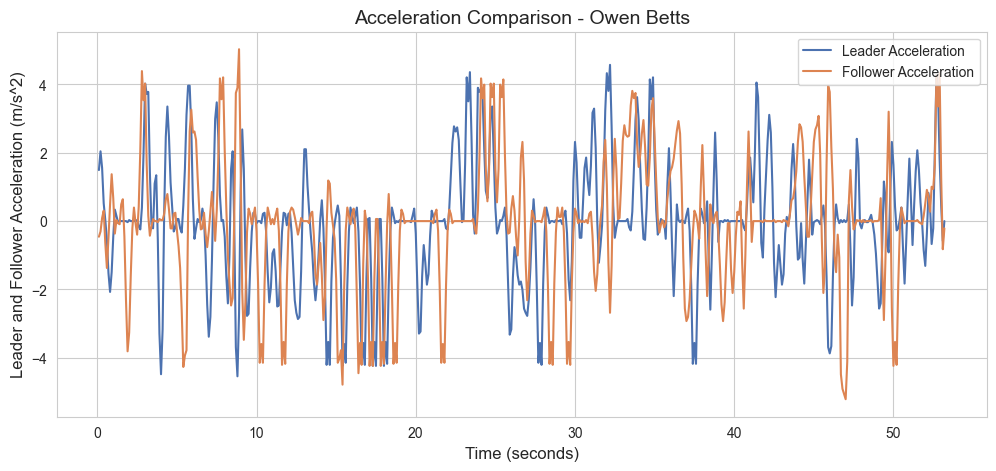

In [25]:
# Now replicating the same but visualizing acceleration
# Select a trajectory number
trajectory_number = 16 # vehicle pair x

# select the data based on the subset 

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

# Plot the position of both vehicles over time
# follow similar steps of what we learned
# but here you need to plot two lines together:
    # one lineplot for leader position vs time 
    # another lineplot for follower position vs time

plt.figure(figsize = (12,5))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_acc(m/s^2)', label = 'Leader Acceleration')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_acc(m/s^2)', label = 'Follower Acceleration')

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Leader and Follower Acceleration (m/s^2)', fontsize = 12)
plt.title('Acceleration Comparison - Owen Betts', fontsize = 14)
plt.legend()

plt.show()


C:\Users\Olbet\AppData\Local\Temp\ipykernel_40600\3703776657.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


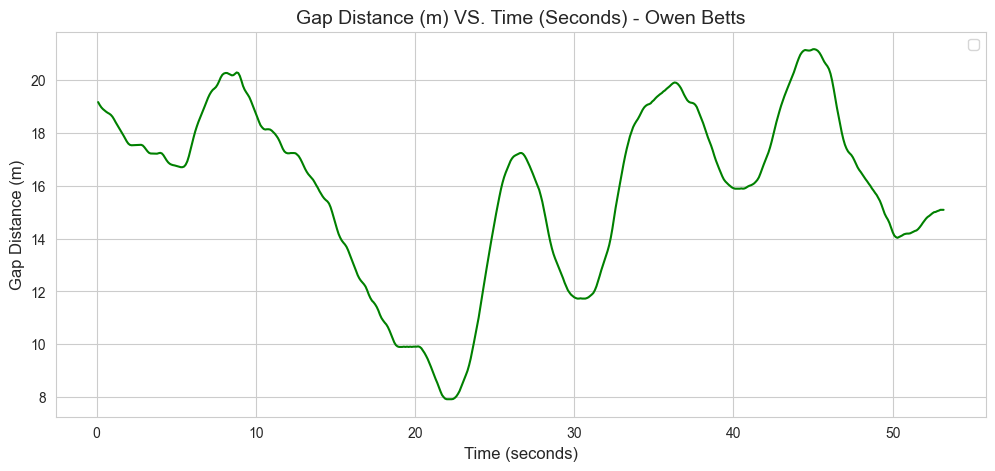

In [32]:
# Now try to plot the gap distance between two vehicle pairs. Gap = position of leader - position of follower
# Plot the gap distance over time 

## Set up the data
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values

plt.figure(figsize = (12,5))
plt.plot(data_subset['Time'], gap_distance, color = 'green', linewidth = 1.5)

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Gap Distance (m)', fontsize = 12)
plt.title('Gap Distance (m) VS. Time (Seconds) - Owen Betts', fontsize = 14)
plt.legend()

plt.show()

### Comprehensive Vehicle Pair Dashboard

Now let's combine everything we know to create a **comprehensive dashboard** for a vehicle pair. We will use subplots to show trajectory, speed, acceleration, and gap distance all in one figure. This is the kind of analysis a transportation engineer would create to understand car-following behavior.

Text(0.5, 0.98, 'Vehicle Trajectory Analysis - Owen Betts')

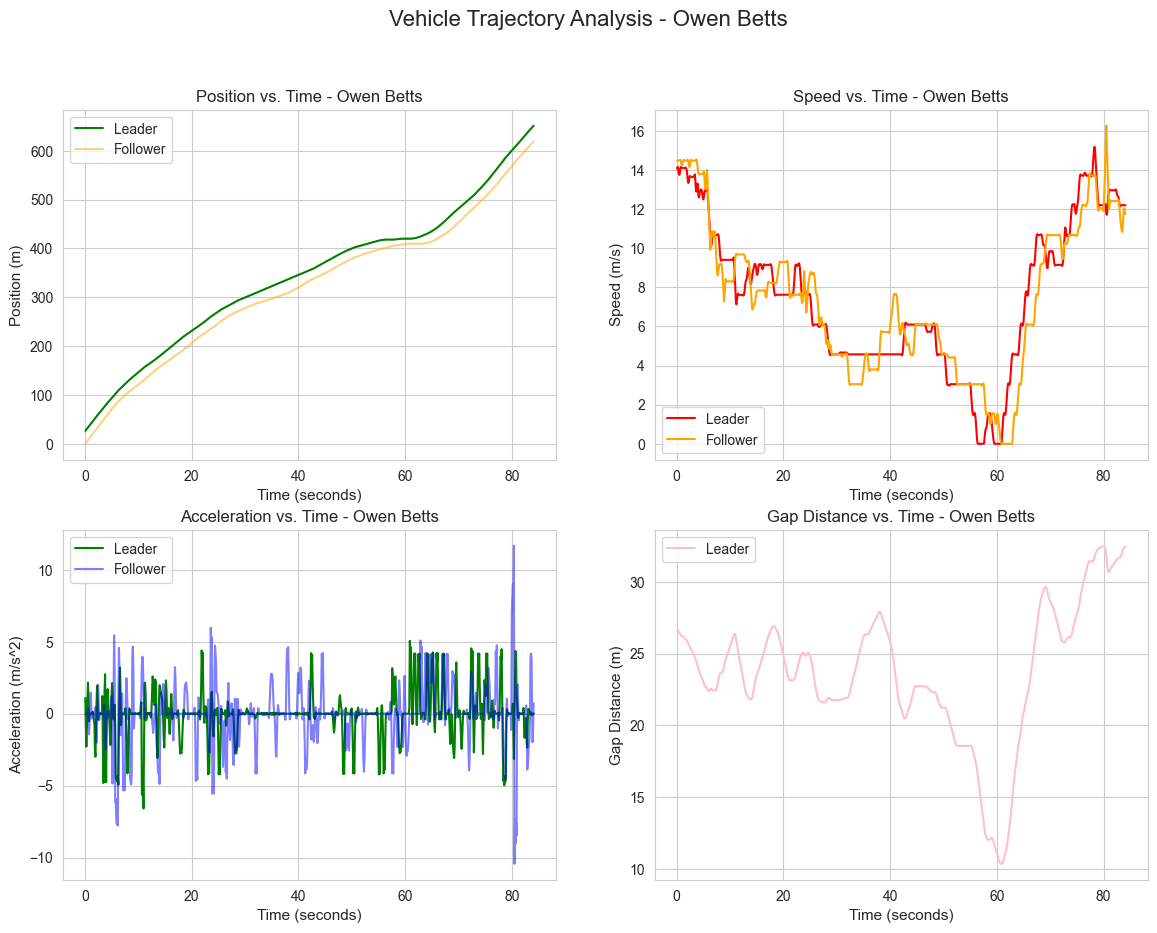

In [47]:
# Create a 2x2 subplot figure showing: trajectory, speed, acceleration, and gap for one vehicle pair

# Step 1: Select a trajectory number and create the subset
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values

# Step 2: Create the figure with 2 rows and 2 columns
# hint: fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig, axes = plt.subplots(2, 2, figsize = (14,10))

# Step 3: Top-left (axes[0,0]): Position vs Time for both leader and follower
axes[0,0].plot(time, data_subset['leader_position(m)'].values, linewidth = 1.5, label = 'Leader', color = 'green')
axes[0,0].plot(time, data_subset['follower_position(m)'].values, linewidth = 1.5, label = 'Follower', color = 'orange', alpha = 0.5)
axes[0,0].set_ylabel('Position (m)', fontsize=11)
axes[0,0].set_xlabel('Time (seconds)', fontsize = 11)
axes[0,0].set_title('Position vs. Time - Owen Betts', fontsize=12)
axes[0,0].legend(fontsize = 10)
# Step 4: Top-right (axes[0,1]): Speed vs Time for both leader and follower
axes[0,1].plot(time, data_subset['leader_speed(m/s)'].values, linewidth = 1.5, label = 'Leader', color = 'red')
axes[0,1].plot(time, data_subset['follower_speed(m/s)'].values, linewidth = 1.5, label = 'Follower', color = 'orange')
axes[0,1].set_ylabel('Speed (m/s)', fontsize=11)
axes[0,1].set_xlabel('Time (seconds)', fontsize = 11)
axes[0,1].set_title('Speed vs. Time - Owen Betts', fontsize=12)
axes[0,1].legend(fontsize = 10)

# Step 5: Bottom-left (axes[1,0]): Acceleration vs Time for both leader and follower
axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'].values, linewidth = 1.5, label = 'Leader', color = 'green')
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'].values, linewidth = 1.5, label = 'Follower', color = 'blue', alpha = 0.5)
axes[1,0].set_ylabel('Acceleration (m/s^2)', fontsize=11)
axes[1,0].set_xlabel('Time (seconds)', fontsize = 11)
axes[1,0].set_title('Acceleration vs. Time - Owen Betts', fontsize=12)
axes[1,0].legend(fontsize = 10)

# Step 6: Bottom-right (axes[1,1]): Gap Distance vs Time
axes[1,1].plot(time, gap_distance, linewidth = 1.5, label = 'Leader', color = 'pink')

axes[1,1].set_ylabel('Gap Distance (m)', fontsize=11)
axes[1,1].set_xlabel('Time (seconds)', fontsize = 11)
axes[1,1].set_title('Gap Distance vs. Time - Owen Betts', fontsize=12)
axes[1,1].legend(fontsize = 10)

# Step 7: Add title for the whole figure and adjust layout

fig.suptitle("Vehicle Trajectory Analysis - Owen Betts", fontsize=16)

### Lab Activity #4: Dashboard customization
In the Dashboard we created above, show you can do the following:
1. Change the colors of the plot lines
2. Choose different trajectories than Dr. Lane did in class
3. Change the transparency of the lines
4. Put one of the plots in a different location (i.e. switch the top left to the bottom right)